# Traffic → Pollution → Health

## A Multi-Step Statistical Analysis of Urban Traffic, Air Pollution, and Estimated Health Risk



## Introduction

Urban traffic is one of the major contributors to local air pollution in large cities. Pollutants such as PM2.5, PM10, and NO₂ are associated with increased respiratory and cardiovascular risks.

This project investigates the following statistical pathway:

Traffic intensity → Air pollution → Estimated health risk

The objective is to quantify how traffic affects pollution and how pollution can be translated into estimated health impact using established epidemiological formulas.

In [39]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


from src.data_loading import (
    load_csv,
    standardize_columns,
    parse_date_column,
    basic_info,
)
from src.cleaning import (
    clean_numeric_columns,
    drop_invalid_dates,
    remove_negative_values,
    missing_value_summary,
)
from src.features import (
    add_lag_features,
    add_rolling_features,
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## Data Loading

In this section, the project loads and inspects the primary dataset containing traffic, weather, and air pollution observations.

In [40]:
from pathlib import Path

raw_dir = project_root / "data" / "raw"

for file in raw_dir.iterdir():
    print(file.name)

AirQualityUCI.csv
API_SH.STA.AIRP.P5_DS2_en_csv_v2_9827.csv


In [41]:
uci_path = project_root / "data" / "raw" / "AirQualityUCI.csv"
wb_path = project_root / "data" / "raw" / "API_SH.STA.AIRP.P5_DS2_en_csv_v2_9827.csv"

uci_df = pd.read_csv(
    uci_path,
    sep=";",
    decimal=",",
    na_values=[-200]
)

uci_df = uci_df.dropna(axis=1, how="all")


uci_df = standardize_columns(uci_df)


wb_df = pd.read_csv(wb_path, skiprows=4)
wb_df = standardize_columns(wb_df)


print("UCI Air Quality dataset")
basic_info(uci_df)

print("\nWorld Bank mortality dataset")
basic_info(wb_df)

UCI Air Quality dataset
Shape: (9471, 15)

Columns:
['date', 'time', 'co(gt)', 'pt08.s1(co)', 'nmhc(gt)', 'c6h6(gt)', 'pt08.s2(nmhc)', 'nox(gt)', 'pt08.s3(nox)', 'no2(gt)', 'pt08.s4(no2)', 'pt08.s5(o3)', 't', 'rh', 'ah']

Missing values:
date              114
time              114
co(gt)           1797
pt08.s1(co)       480
nmhc(gt)         8557
c6h6(gt)          480
pt08.s2(nmhc)     480
nox(gt)          1753
pt08.s3(nox)      480
no2(gt)          1756
pt08.s4(no2)      480
pt08.s5(o3)       480
t                 480
rh                480
ah                480
dtype: int64

World Bank mortality dataset
Shape: (266, 71)

Columns:
['country_name', 'country_code', 'indicator_name', 'indicator_code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996

## Exploratory Data Analysis

This section cleans the UCI Air Quality dataset and explores the main pollutant and meteorological variables.

In [42]:
uci_clean = uci_df.copy()

uci_clean["datetime"] = pd.to_datetime(
    uci_clean["date"].astype(str) + " " + uci_clean["time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

uci_clean = uci_clean.dropna(subset=["datetime"])


for col in uci_clean.columns:
    if col not in ["date", "time", "datetime"]:
        uci_clean[col] = pd.to_numeric(uci_clean[col], errors="coerce")

uci_clean = uci_clean.set_index("datetime").sort_index()

print("Cleaned dataset shape:", uci_clean.shape)
uci_clean.head()

Cleaned dataset shape: (9357, 15)


,date,time,co(gt),pt08.s1(co),nmhc(gt),c6h6(gt),pt08.s2(nmhc),nox(gt),pt08.s3(nox),no2(gt),pt08.s4(no2),pt08.s5(o3),t,rh,ah
datetime,,,,,,,,,,,,,,,
2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Missing Value Summary

In [43]:
missing_summary = missing_value_summary(uci_clean)
missing_summary.head(15)

,missing_count,missing_ratio
nmhc(gt),8443,0.902319
co(gt),1683,0.179865
no2(gt),1642,0.175484
nox(gt),1639,0.175163
pt08.s2(nmhc),366,0.039115
c6h6(gt),366,0.039115
pt08.s1(co),366,0.039115
pt08.s5(o3),366,0.039115
t,366,0.039115
pt08.s3(nox),366,0.039115


Select Key Variables

In [44]:
key_vars = [
    "co(gt)",
    "nox(gt)",
    "no2(gt)",
    "t",
    "rh",
    "ah"
]

uci_clean[key_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
co(gt),7674.0,2.152750,1.453252,0.1000,1.1000,1.8000,2.9000,11.900
nox(gt),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
no2(gt),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
t,8991.0,18.317829,8.832116,-1.9000,11.8000,17.8000,24.4000,44.600
rh,8991.0,49.234201,17.316892,9.2000,35.8000,49.6000,62.5000,88.700
ah,8991.0,1.025530,0.403813,0.1847,0.7368,0.9954,1.3137,2.231


Distribution Plots

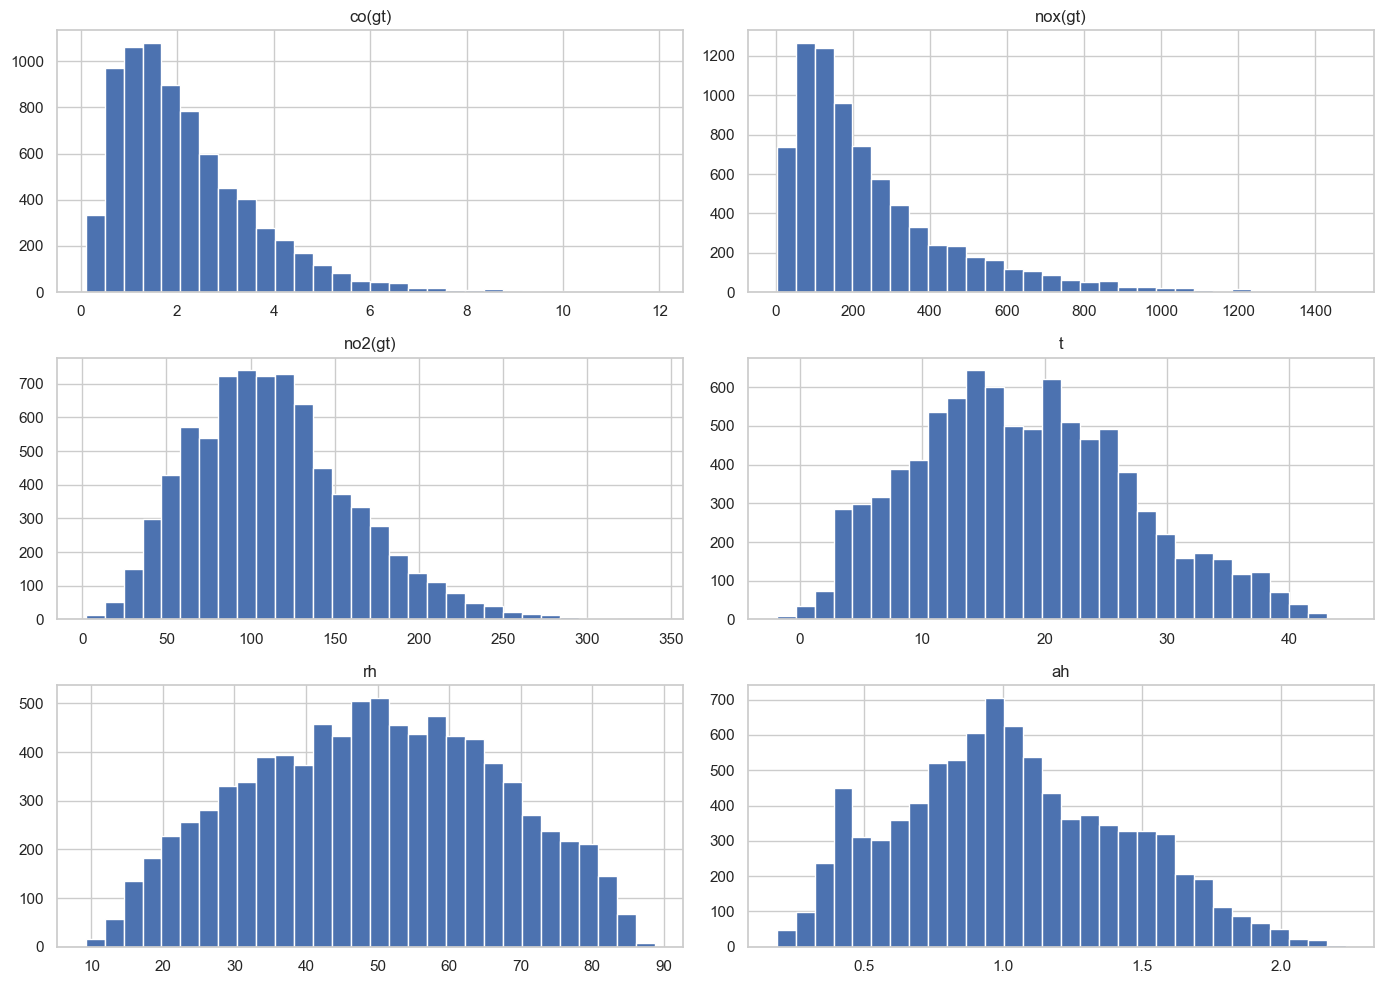

In [45]:
uci_clean[key_vars].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

Correlation Matrix

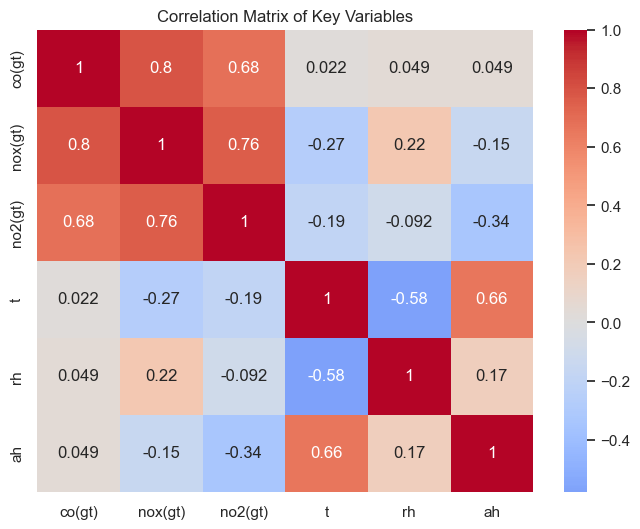

In [46]:
corr = uci_clean[key_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Key Variables")
plt.show()

Scatter Plot: NOx vs NO₂

C:\Users\Radost\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


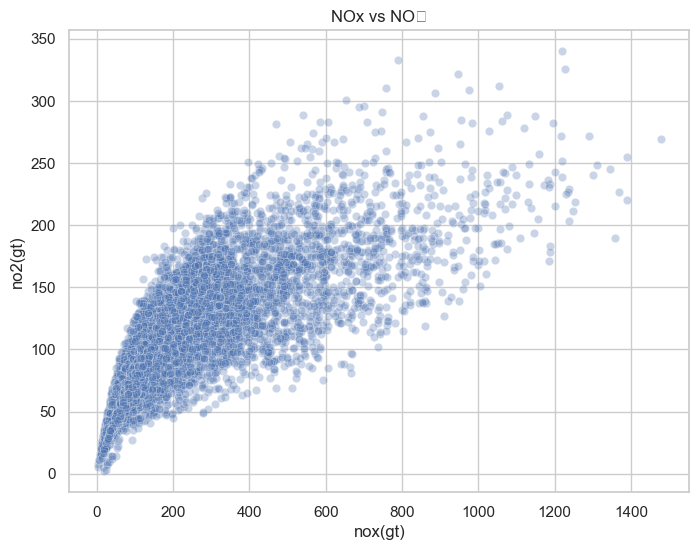

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=uci_clean,
    x="nox(gt)",
    y="no2(gt)",
    alpha=0.3
)
plt.title("NOx vs NO₂")
plt.show()

Monthly Aggregation Preview

In [48]:
monthly = uci_clean[key_vars].resample("ME").mean()
monthly.head()

,co(gt),nox(gt),no2(gt),t,rh,ah
datetime,,,,,,
2004-03-31,2.292073,143.493852,102.581967,14.390784,50.170784,0.789413
2004-04-30,2.303838,140.279835,96.880658,16.800722,50.708514,0.920774
2004-05-31,1.940034,122.132107,93.148829,20.281233,43.542329,0.957332
2004-06-30,1.900000,122.064715,94.084877,26.476540,39.850733,1.275380
2004-07-31,1.784946,126.754213,104.120956,29.419112,33.054240,1.242711


Monthly Trends

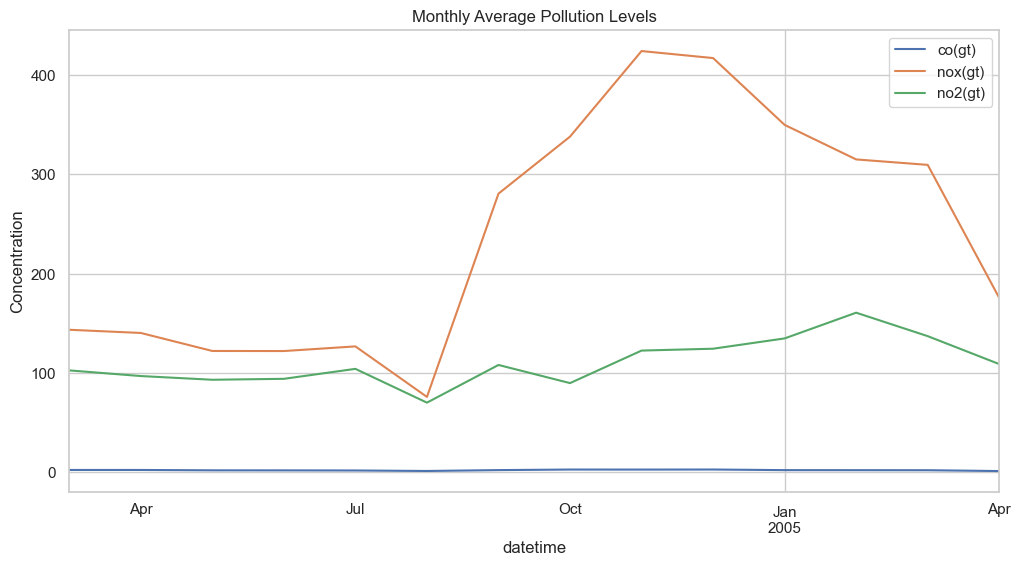

In [49]:
monthly[["co(gt)", "nox(gt)", "no2(gt)"]].plot(
    figsize=(12, 6)
)
plt.title("Monthly Average Pollution Levels")
plt.ylabel("Concentration")
plt.show()